# Object Detection and Tracking with OpenCV

This notebook teaches classical object detection and object tracking from video.

We will learn:

1. What object detection means
2. Reading images and videos
3. Color-based segmentation
4. Binary masks
5. Morphological operations
6. Connected components
7. Contour detection
8. Area filtering
9. Centroids
10. Bounding boxes
11. Building an object detector
12. Applying detection to video
13. Why detection alone is not tracking
14. Object tracking pipeline
15. Kalman filtering
16. Prediction
17. Detection-to-track assignment
18. Track updating
19. Track creation
20. Track confirmation
21. Lost-track removal
22. Complete cell-tracking system
23. Visualization and analysis
24. Parameter experiments

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.optimize import linear_sum_assignment

from IPython.display import display, clear_output
from collections import defaultdict

%matplotlib inline

print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)

OpenCV: 5.0.0
NumPy: 2.5.1


In [3]:
# Change these paths according to your project

PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "output"

OUTPUT_DIR.mkdir(exist_ok=True)

print("Project:", PROJECT_ROOT)
print("Data:", DATA_DIR)
print("Output:", OUTPUT_DIR)

Project: c:\Users\Sanjarbek\maab\cv\computer-vision-roadmap\content\object-tracking
Data: c:\Users\Sanjarbek\maab\cv\computer-vision-roadmap\content\object-tracking\data
Output: c:\Users\Sanjarbek\maab\cv\computer-vision-roadmap\content\object-tracking\output


In [4]:
VIDEO_PATH = PROJECT_ROOT / "assets" / "CellVideo.avi"

## Object Detection

Object detection answers:

> Where are the objects in this image?

For each detected object we usually want:

- Centroid
- Bounding box
- Area
- Confidence
- Class label

For this lesson we use classical computer vision rather than a neural-network detector.

Our pipeline is:
```
Image
    ↓
Color segmentation
    ↓
Binary mask
    ↓
Morphological processing
    ↓
Connected components / contours
    ↓
Area filtering
    ↓
Centroid + bounding box
    ↓
Detected objects
```

In [5]:
IMAGE_PATH = PROJECT_ROOT / "assets" / "image.png"

image = cv2.imread(str(IMAGE_PATH))

if image is None:
    print("Image not found:", IMAGE_PATH)
else:
    print("Shape:", image.shape)

Shape: (907, 1318, 3)


In [6]:
def show_image(image, title="Image", figsize=(10, 6)):
    """
    Display an OpenCV image using Matplotlib.
    Converts BGR -> RGB when necessary.
    """
    
    plt.figure(figsize=figsize)
    
    if len(image.shape) == 3:
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        plt.imshow(image_rgb)
    else:
        plt.imshow(image, cmap="gray")
    
    plt.title(title)
    plt.axis("off")
    plt.show()

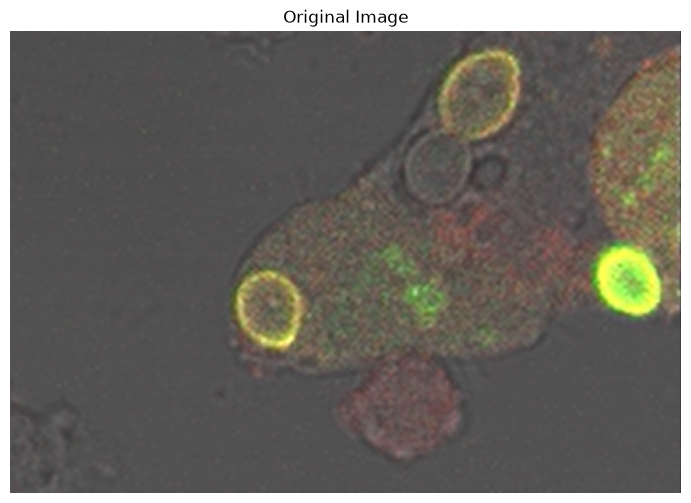

In [7]:
if image is not None:
    show_image(image, "Original Image")

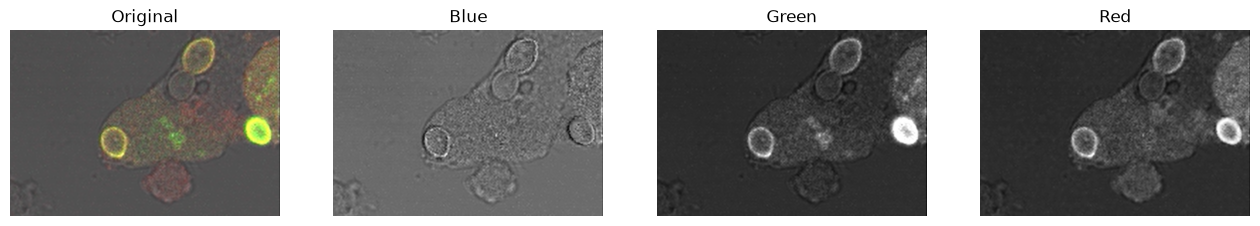

In [8]:
if image is not None:

    b, g, r = cv2.split(image)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original")

    axes[1].imshow(b, cmap="gray")
    axes[1].set_title("Blue")

    axes[2].imshow(g, cmap="gray")
    axes[2].set_title("Green")

    axes[3].imshow(r, cmap="gray")
    axes[3].set_title("Red")

    for ax in axes:
        ax.axis("off")

    plt.show()

In [9]:
def segment_cells_bgr(image, green_min=175):
    """
    Segment bright-green regions.

    Equivalent idea to the MATLAB Color Thresholder
    used in the uploaded lesson.
    """
    
    b, g, r = cv2.split(image)
    
    mask = (
        (b >= 0) &
        (b <= 255) &
        (g >= green_min) &
        (g <= 255) &
        (r >= 0) &
        (r <= 255)
    )
    
    return (mask.astype(np.uint8) * 255)

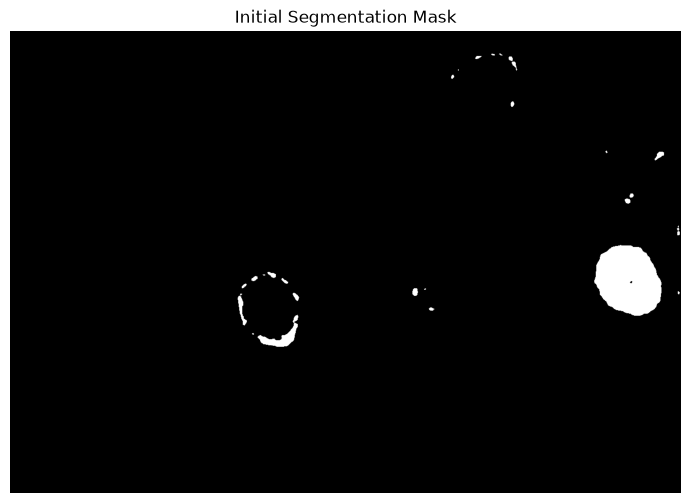

In [10]:
if image is not None:
    mask = segment_cells_bgr(image)
    show_image(mask, "Initial Segmentation Mask")

## Binary Mask

A binary mask contains only two possible values:

0   → background
255 → detected region

Conceptually:

Original image

        ↓

Pixel satisfies color condition?

        ↓

YES → 255
NO  → 0

The mask converts the detection problem from:

"Understand this entire image"

into:

"Find connected regions satisfying our condition."

In [11]:
def erode_mask(mask, radius=4):
    """
    Erode a binary mask using a circular kernel.
    """
    
    size = 2 * radius + 1
    
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (size, size)
    )
    
    return cv2.erode(mask, kernel)

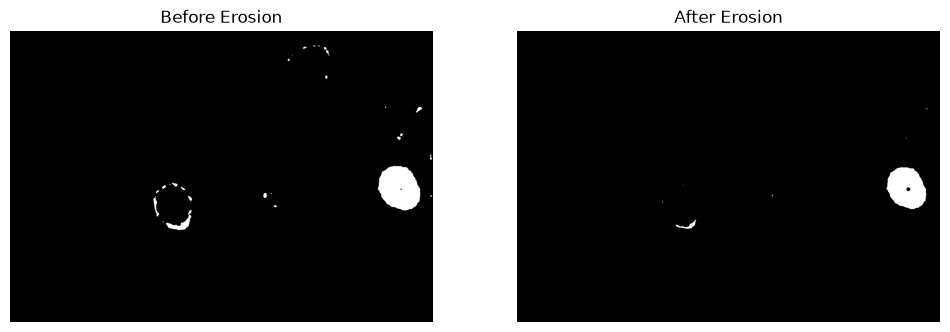

In [12]:
if image is not None:

    eroded = erode_mask(mask, radius=4)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(mask, cmap="gray")
    axes[0].set_title("Before Erosion")
    axes[0].axis("off")

    axes[1].imshow(eroded, cmap="gray")
    axes[1].set_title("After Erosion")
    axes[1].axis("off")

    plt.show()

In [13]:
def fill_holes(mask):
    """
    Fill holes inside foreground objects.
    """
    
    flood = mask.copy()
    
    h, w = mask.shape
    
    flood_mask = np.zeros(
        (h + 2, w + 2),
        np.uint8
    )
    
    cv2.floodFill(
        flood,
        flood_mask,
        (0, 0),
        255
    )
    
    flood_inv = cv2.bitwise_not(flood)
    
    filled = mask | flood_inv
    
    return filled

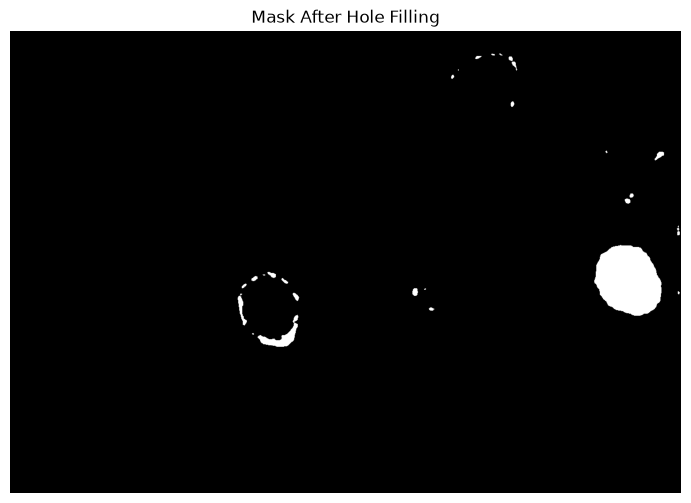

In [14]:
if image is not None:

    filled = fill_holes(mask)

    show_image(
        filled,
        "Mask After Hole Filling"
    )

In [15]:
def segment_cells(
    image,
    green_min=175,
    erosion_radius=4
):
    """
    Segment cells using color thresholding
    followed by hole filling and erosion.
    """
    
    # 1. Color threshold
    mask = segment_cells_bgr(
        image,
        green_min=green_min
    )
    
    # 2. Fill holes
    mask = fill_holes(mask)
    
    # 3. Erosion
    mask = erode_mask(
        mask,
        radius=erosion_radius
    )
    
    return mask

## Connected Components

Suppose the mask contains:

    ███        ███

       ███

    ███        ███

Each connected region represents a candidate object.

Connected component analysis allows us to calculate:

- Area
- Centroid
- Bounding box
- Width
- Height

In [16]:
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    mask,
    connectivity=8
)

print("Number of components:", num_labels)

Number of components: 32


In [17]:
for label in range(1, num_labels):
    
    x = stats[label, cv2.CC_STAT_LEFT]
    y = stats[label, cv2.CC_STAT_TOP]
    w = stats[label, cv2.CC_STAT_WIDTH]
    h = stats[label, cv2.CC_STAT_HEIGHT]
    area = stats[label, cv2.CC_STAT_AREA]
    
    cx, cy = centroids[label]
    
    print(
        f"Object {label}: "
        f"area={area}, "
        f"bbox=({x}, {y}, {w}, {h}), "
        f"centroid=({cx:.1f}, {cy:.1f})"
    )

Object 1: area=19, bbox=(945, 44, 7, 4), centroid=(948.0, 45.8)
Object 2: area=14, bbox=(960, 44, 7, 4), centroid=(962.9, 45.7)
Object 3: area=50, bbox=(913, 49, 13, 6), centroid=(918.4, 51.1)
Object 4: area=58, bbox=(979, 50, 8, 9), centroid=(982.6, 53.7)
Object 5: area=69, bbox=(985, 60, 10, 12), centroid=(989.4, 64.7)
Object 6: area=9, bbox=(993, 73, 3, 5), centroid=(993.8, 74.7)
Object 7: area=4, bbox=(879, 75, 2, 3), centroid=(879.8, 76.0)
Object 8: area=35, bbox=(866, 86, 6, 8), centroid=(868.4, 89.4)
Object 9: area=59, bbox=(983, 138, 7, 11), centroid=(985.8, 143.0)
Object 10: area=13, bbox=(1169, 235, 4, 5), centroid=(1170.5, 236.8)
Object 11: area=162, bbox=(1265, 237, 19, 17), centroid=(1274.7, 243.6)
Object 12: area=53, bbox=(1216, 319, 9, 8), centroid=(1219.8, 322.5)
Object 13: area=87, bbox=(1207, 329, 11, 10), centroid=(1212.1, 333.3)
Object 14: area=5, bbox=(1311, 382, 2, 3), centroid=(1311.6, 383.2)
Object 15: area=19, bbox=(1309, 386, 5, 6), centroid=(1311.2, 388.5)
Ob

In [18]:
def filter_components_by_area(
    mask,
    min_area=50,
    max_area=400
):
    """
    Keep only connected components whose area
    falls within [min_area, max_area].
    """
    
    num_labels, labels, stats, centroids = \
        cv2.connectedComponentsWithStats(
            mask,
            connectivity=8
        )
    
    filtered = np.zeros_like(mask)
    
    detections = []
    
    for label in range(1, num_labels):
        
        area = stats[label, cv2.CC_STAT_AREA]
        
        if min_area <= area <= max_area:
            
            filtered[labels == label] = 255
            
            x = stats[label, cv2.CC_STAT_LEFT]
            y = stats[label, cv2.CC_STAT_TOP]
            w = stats[label, cv2.CC_STAT_WIDTH]
            h = stats[label, cv2.CC_STAT_HEIGHT]
            
            cx, cy = centroids[label]
            
            detections.append({
                "centroid": (float(cx), float(cy)),
                "bbox": (int(x), int(y), int(w), int(h)),
                "area": int(area)
            })
    
    return filtered, detections

In [19]:
def draw_detections(image, detections):
    """
    Draw bounding boxes and centroids.
    """
    
    output = image.copy()
    
    for i, detection in enumerate(detections):
        
        x, y, w, h = detection["bbox"]
        cx, cy = detection["centroid"]
        
        # Bounding box
        cv2.rectangle(
            output,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            2
        )
        
        # Centroid
        cv2.circle(
            output,
            (int(cx), int(cy)),
            4,
            (0, 0, 255),
            -1
        )
        
        # Object ID
        cv2.putText(
            output,
            f"Object {i + 1}",
            (x, max(y - 5, 15)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 0, 0),
            1
        )
    
    return output

In [20]:
def detect_cells(
    frame,
    green_min=175,
    erosion_radius=4,
    min_area=50,
    max_area=400
):
    """
    Complete cell/object detector.
    
    Returns:
        detections
        mask
    """
    
    # Step 1: segmentation
    mask = segment_cells(
        frame,
        green_min=green_min,
        erosion_radius=erosion_radius
    )
    
    # Step 2: area filtering
    filtered_mask, detections = filter_components_by_area(
        mask,
        min_area=min_area,
        max_area=max_area
    )
    
    return detections, filtered_mask

Detected objects: 0


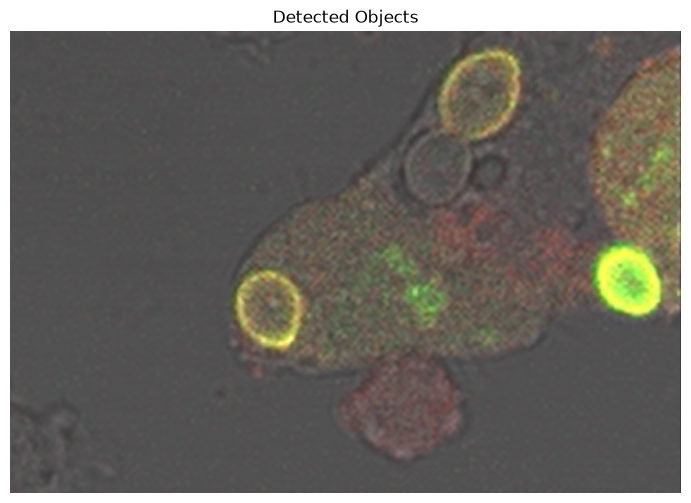

In [21]:
if image is not None:
    
    detections, filtered_mask = detect_cells(image)
    
    result = draw_detections(
        image,
        detections
    )
    
    print("Detected objects:", len(detections))
    
    show_image(
        result,
        "Detected Objects"
    )

In [22]:
for i, detection in enumerate(detections):
    
    print(f"\nObject {i + 1}")
    print("Centroid:", detection["centroid"])
    print("Bounding box:", detection["bbox"])
    print("Area:", detection["area"])

# Detection vs Tracking

Detection:

    Frame 1 → find objects
    Frame 2 → find objects
    Frame 3 → find objects

The detector doesn't inherently know:

"Object 3 in frame 3 is the same object
as Object 3 in frame 2."

Tracking adds identity.

    Detection
        ↓
    Prediction
        ↓
    Assignment
        ↓
    Update
        ↓
    Track identity

In [23]:
# Automatically find common video files

video_candidates = list(
    (PROJECT_ROOT / "assets").glob("*.mp4")
) + list(
    (PROJECT_ROOT / "assets").glob("*.avi")
)

video_candidates

[WindowsPath('c:/Users/Sanjarbek/maab/cv/computer-vision-roadmap/content/object-tracking/assets/CellVideo.avi')]

In [24]:
VIDEO_PATH = video_candidates[0]

print("Using:", VIDEO_PATH)

Using: c:\Users\Sanjarbek\maab\cv\computer-vision-roadmap\content\object-tracking\assets\CellVideo.avi


In [25]:
cap = cv2.VideoCapture(str(VIDEO_PATH))

if not cap.isOpened():
    raise RuntimeError(f"Could not open video: {VIDEO_PATH}")

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

duration = frame_count / fps if fps else 0

print("FPS:", fps)
print("Frames:", frame_count)
print("Resolution:", width, "x", height)
print("Duration:", duration, "seconds")

cap.release()

FPS: 10.0
Frames: 300
Resolution: 192 x 155
Duration: 30.0 seconds


Successfully read: True


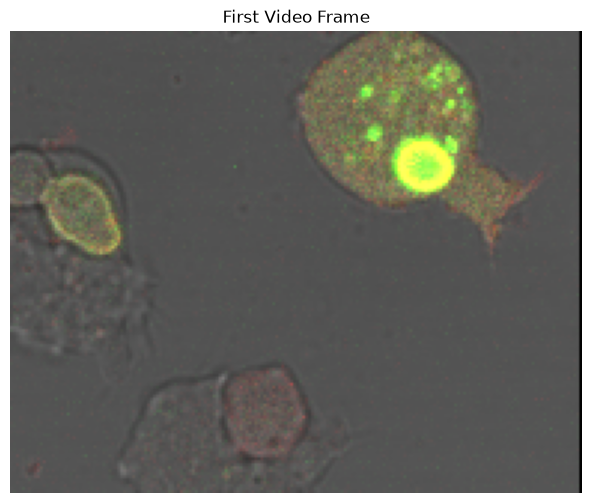

In [26]:
cap = cv2.VideoCapture(str(VIDEO_PATH))

ret, frame = cap.read()

cap.release()

print("Successfully read:", ret)

if ret:
    show_image(frame, "First Video Frame")

Detected: 1


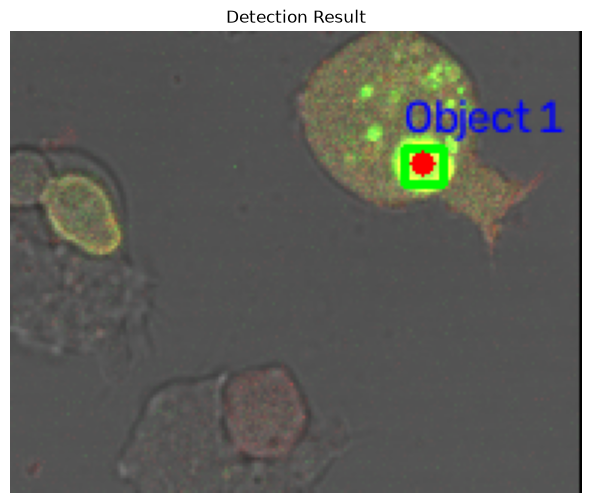

In [27]:
detections, mask = detect_cells(frame)

result = draw_detections(
    frame,
    detections
)

print("Detected:", len(detections))

show_image(result, "Detection Result")

In [28]:
def visualize_detection_pipeline(frame):
    
    segmentation = segment_cells(frame)
    
    filled = fill_holes(
        segment_cells_bgr(frame)
    )
    
    eroded = erode_mask(filled)
    
    filtered, detections = filter_components_by_area(
        eroded
    )
    
    result = draw_detections(
        frame,
        detections
    )
    
    fig, axes = plt.subplots(
        1, 5,
        figsize=(20, 4)
    )
    
    axes[0].imshow(
        cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    )
    axes[0].set_title("Original")
    
    axes[1].imshow(
        segmentation,
        cmap="gray"
    )
    axes[1].set_title("Color Mask")
    
    axes[2].imshow(
        filled,
        cmap="gray"
    )
    axes[2].set_title("Filled")
    
    axes[3].imshow(
        filtered,
        cmap="gray"
    )
    axes[3].set_title("Area Filtered")
    
    axes[4].imshow(
        cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
    )
    axes[4].set_title("Detections")
    
    for ax in axes:
        ax.axis("off")
    
    plt.show()

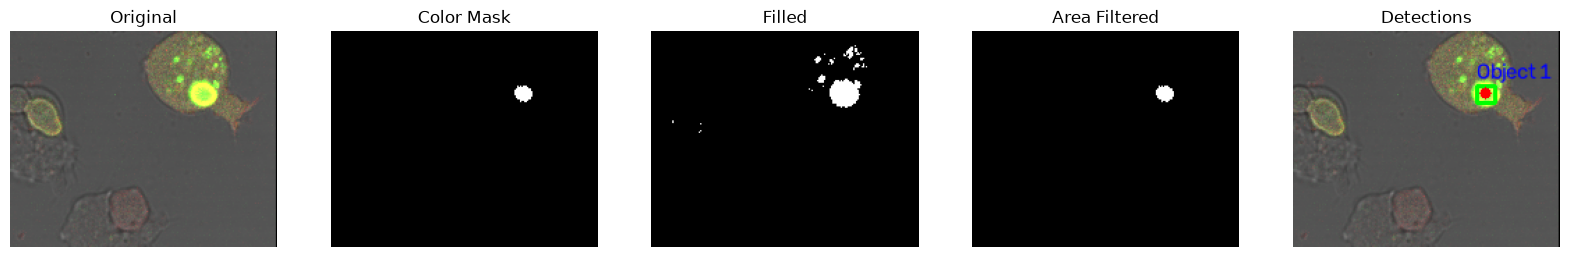

In [29]:
visualize_detection_pipeline(frame)

In [30]:
def detect_video(
    video_path,
    output_path,
    green_min=175,
    erosion_radius=4,
    min_area=50,
    max_area=400
):
    
    cap = cv2.VideoCapture(str(video_path))
    
    if not cap.isOpened():
        raise RuntimeError("Could not open video")
    
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    
    writer = cv2.VideoWriter(
        str(output_path),
        fourcc,
        fps,
        (width, height)
    )
    
    total_frames = int(
        cap.get(cv2.CAP_PROP_FRAME_COUNT)
    )
    
    frame_number = 0
    
    detection_counts = []
    
    while True:
        
        ret, frame = cap.read()
        
        if not ret:
            break
        
        detections, _ = detect_cells(
            frame,
            green_min=green_min,
            erosion_radius=erosion_radius,
            min_area=min_area,
            max_area=max_area
        )
        
        result = draw_detections(
            frame,
            detections
        )
        
        writer.write(result)
        
        detection_counts.append(
            len(detections)
        )
        
        frame_number += 1
        
        if frame_number % 50 == 0:
            print(
                f"Processed "
                f"{frame_number}/{total_frames}"
            )
    
    cap.release()
    writer.release()
    
    return detection_counts

In [31]:
DETECTION_OUTPUT = OUTPUT_DIR / "object_detection.mp4"

detection_counts = detect_video(
    VIDEO_PATH,
    DETECTION_OUTPUT
)

print("Saved:", DETECTION_OUTPUT)

Processed 50/300
Processed 100/300
Processed 150/300
Processed 200/300
Processed 250/300
Processed 300/300
Saved: c:\Users\Sanjarbek\maab\cv\computer-vision-roadmap\content\object-tracking\output\object_detection.mp4


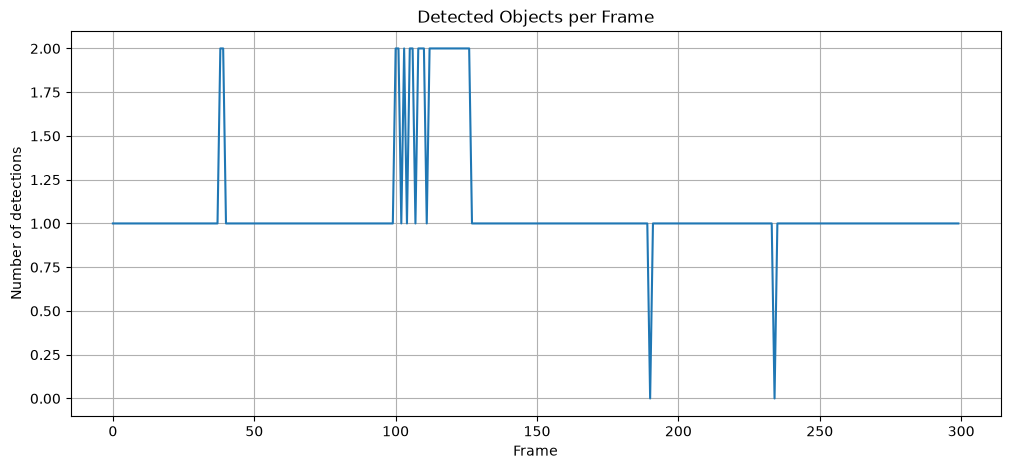

In [32]:
plt.figure(figsize=(12, 5))

plt.plot(detection_counts)

plt.xlabel("Frame")
plt.ylabel("Number of detections")
plt.title("Detected Objects per Frame")

plt.grid(True)
plt.show()

# Object Tracking

The tracking system follows this architecture:

             VIDEO FRAME
                  │
                  ▼
             DETECTION
                  │
                  ▼
             PREDICTION
                  │
                  ▼
          ASSIGNMENT / MATCHING
                  │
                  ▼
               UPDATE
                  │
                  ▼
             TRACK TABLE
                  │
                  ├── Track ID
                  ├── Position
                  ├── Age
                  ├── Visibility
                  ├── Kalman filter
                  └── Confirmation

In [33]:
class Track:

    def __init__(self, track_id, centroid, frame):

        self.track_id = track_id

        self.detected_position = np.array(
            centroid,
            dtype=np.float32
        )

        self.tracked_position = self.detected_position.copy()

        self.predicted_position = (
            self.detected_position.copy()
        )

        self.age = 1
        self.total_visible_count = 1
        self.consecutive_invisible_count = 0

        self.confirmed = False

        self.first_frame = frame

        # ==========================================
        # Kalman Filter
        # ==========================================

        # 4 state variables:
        # x, y, vx, vy
        self.kalman = cv2.KalmanFilter(
            4,  # state dimension
            2   # measurement dimension
        )

        # ==========================================
        # Transition Matrix
        # ==========================================

        self.kalman.transitionMatrix = np.array(
            [
                [1, 0, 1, 0],
                [0, 1, 0, 1],
                [0, 0, 1, 0],
                [0, 0, 0, 1]
            ],
            dtype=np.float32
        )

        # ==========================================
        # Measurement Matrix
        # ==========================================

        # We only measure x and y
        self.kalman.measurementMatrix = np.array(
            [
                [1, 0, 0, 0],
                [0, 1, 0, 0]
            ],
            dtype=np.float32
        )

        # ==========================================
        # Process Noise
        # ==========================================

        self.kalman.processNoiseCov = (
            np.eye(4, dtype=np.float32) * 0.03
        )

        # ==========================================
        # Measurement Noise
        # ==========================================

        self.kalman.measurementNoiseCov = (
            np.eye(2, dtype=np.float32) * 1
        )

        # ==========================================
        # Initial Error Covariance
        # ==========================================

        self.kalman.errorCovPost = (
            np.eye(4, dtype=np.float32)
        )

        # ==========================================
        # IMPORTANT:
        # State must be 4 x 1
        # ==========================================

        self.kalman.statePost = np.array(
            [
                [centroid[0]],
                [centroid[1]],
                [0.0],
                [0.0]
            ],
            dtype=np.float32
        )

# Kalman Filter

The Kalman filter estimates where the object should be.

State:

[x, y, vx, vy]

where:

x  = horizontal position
y  = vertical position
vx = horizontal velocity
vy = vertical velocity

Prediction:

previous state
      ↓
motion model
      ↓
predicted state

In [34]:
def predict_tracks(tracks):

    for track in tracks:

        prediction = track.kalman.predict()

        track.predicted_position = np.array(
            [
                prediction[0, 0],
                prediction[1, 0]
            ],
            dtype=np.float32
        )

    return tracks

In [35]:
def calculate_cost_matrix(
    tracks,
    detections
):
    
    if len(tracks) == 0 or len(detections) == 0:
        return np.empty(
            (len(tracks), len(detections))
        )
    
    cost = np.zeros(
        (len(tracks), len(detections))
    )
    
    for i, track in enumerate(tracks):
        
        predicted = track.predicted_position
        
        for j, detection in enumerate(detections):
            
            detected = np.array(
                detection["centroid"]
            )
            
            cost[i, j] = np.linalg.norm(
                predicted - detected
            )
    
    return cost

In [36]:
def assign_detections_to_tracks(
    tracks,
    detections,
    max_distance=200
):
    
    if len(tracks) == 0 or len(detections) == 0:
        return [], list(range(len(tracks))), list(range(len(detections)))
    
    cost = calculate_cost_matrix(
        tracks,
        detections
    )
    
    track_indices, detection_indices = \
        linear_sum_assignment(cost)
    
    assignments = []
    unassigned_tracks = set(range(len(tracks)))
    unassigned_detections = set(range(len(detections)))
    
    for track_idx, detection_idx in zip(
        track_indices,
        detection_indices
    ):
        
        if cost[
            track_idx,
            detection_idx
        ] <= max_distance:
            
            assignments.append(
                (track_idx, detection_idx)
            )
            
            unassigned_tracks.discard(
                track_idx
            )
            
            unassigned_detections.discard(
                detection_idx
            )
    
    return (
        assignments,
        list(unassigned_tracks),
        list(unassigned_detections)
    )

# Track Updating

If a detection matches a track:

    Prediction
         ↓
    Detection
         ↓
    Kalman correction
         ↓
    Updated position

If no detection matches:

    Prediction
         ↓
    Keep predicted position

In [37]:
def update_track(track, detection):

    centroid = np.array(
        detection["centroid"],
        dtype=np.float32
    )

    # ==========================================
    # Measurement must be 2 x 1
    # ==========================================

    measurement = np.array(
        [
            [centroid[0]],
            [centroid[1]]
        ],
        dtype=np.float32
    )

    # ==========================================
    # Kalman correction
    # ==========================================

    corrected = track.kalman.correct(
        measurement
    )

    # ==========================================
    # Store positions
    # ==========================================

    track.detected_position = centroid

    track.tracked_position = np.array(
        [
            corrected[0, 0],
            corrected[1, 0]
        ],
        dtype=np.float32
    )

    track.age += 1

    track.total_visible_count += 1

    track.consecutive_invisible_count = 0

    return track

In [38]:
def update_invisible_track(track):
    
    track.tracked_position = \
        track.predicted_position.copy()
    
    track.age += 1
    
    track.consecutive_invisible_count += 1
    
    return track

In [39]:
def confirm_tracks(
    tracks,
    confirmation_threshold=3
):
    
    for track in tracks:
        
        track.confirmed = (
            track.total_visible_count
            > confirmation_threshold
        )
    
    return tracks

In [40]:
def remove_lost_tracks(
    tracks,
    age_threshold=10,
    visibility_threshold=0.6,
    lost_threshold=10
):
    
    remaining = []
    
    for track in tracks:
        
        visibility = (
            track.total_visible_count
            / track.age
        )
        
        new_track = (
            track.age <= age_threshold
        )
        
        low_visibility = (
            visibility < visibility_threshold
        )
        
        lost = (
            track.consecutive_invisible_count
            >= lost_threshold
        )
        
        delete = (
            (new_track and low_visibility)
            or lost
        )
        
        if not delete:
            remaining.append(track)
    
    return remaining

In [41]:
def create_new_tracks(
    tracks,
    detections,
    unassigned_detections,
    next_track_id,
    frame_number
):
    
    for detection_idx in unassigned_detections:
        
        detection = detections[
            detection_idx
        ]
        
        track = Track(
            next_track_id,
            detection["centroid"],
            frame_number
        )
        
        tracks.append(track)
        
        next_track_id += 1
    
    return tracks, next_track_id

In [42]:
class CellTracker:
    
    def __init__(
        self,
        max_distance=200,
        confirmation_threshold=3,
        age_threshold=10,
        visibility_threshold=0.6,
        lost_threshold=10
    ):
        
        self.tracks = []
        self.next_track_id = 1
        
        self.max_distance = max_distance
        
        self.confirmation_threshold = \
            confirmation_threshold
        
        self.age_threshold = age_threshold
        self.visibility_threshold = \
            visibility_threshold
        
        self.lost_threshold = lost_threshold
        
    def update(
        self,
        detections,
        frame_number
    ):
        
        # --------------------------------
        # 1. Predict
        # --------------------------------
        
        self.tracks = predict_tracks(
            self.tracks
        )
        
        # --------------------------------
        # 2. Assignment
        # --------------------------------
        
        (
            assignments,
            unassigned_tracks,
            unassigned_detections
        ) = assign_detections_to_tracks(
            self.tracks,
            detections,
            self.max_distance
        )
        
        # --------------------------------
        # 3. Update assigned tracks
        # --------------------------------
        
        for (
            track_idx,
            detection_idx
        ) in assignments:
            
            update_track(
                self.tracks[track_idx],
                detections[detection_idx]
            )
        
        # --------------------------------
        # 4. Update invisible tracks
        # --------------------------------
        
        for track_idx in unassigned_tracks:
            
            update_invisible_track(
                self.tracks[track_idx]
            )
        
        # --------------------------------
        # 5. Confirm tracks
        # --------------------------------
        
        self.tracks = confirm_tracks(
            self.tracks,
            self.confirmation_threshold
        )
        
        # --------------------------------
        # 6. Remove lost tracks
        # --------------------------------
        
        self.tracks = remove_lost_tracks(
            self.tracks,
            self.age_threshold,
            self.visibility_threshold,
            self.lost_threshold
        )
        
        # --------------------------------
        # 7. Create new tracks
        # --------------------------------
        
        (
            self.tracks,
            self.next_track_id
        ) = create_new_tracks(
            self.tracks,
            detections,
            unassigned_detections,
            self.next_track_id,
            frame_number
        )
        
        return self.tracks

In [43]:
def draw_tracks(
    frame,
    tracks,
    show_unconfirmed=False
):
    
    output = frame.copy()
    
    for track in tracks:
        
        if not track.confirmed and not show_unconfirmed:
            continue
        
        x, y = map(
            int,
            track.tracked_position
        )
        
        label = f"Cell {track.track_id}"
        
        cv2.circle(
            output,
            (x, y),
            5,
            (0, 0, 255),
            -1
        )
        
        cv2.putText(
            output,
            label,
            (x - 30, y - 15),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            1
        )
    
    return output

In [44]:
cap = cv2.VideoCapture(
    str(VIDEO_PATH)
)

tracker = CellTracker()

frames_to_show = []

for frame_number in range(30):

    ret, frame = cap.read()

    if not ret:
        break

    # ==========================================
    # 1. Detect objects
    # ==========================================

    detections, _ = detect_cells(
        frame
    )

    # ==========================================
    # 2. Update tracker
    # ==========================================

    tracks = tracker.update(
        detections,
        frame_number
    )

    # ==========================================
    # 3. Draw tracks
    # ==========================================

    result = draw_tracks(
        frame,
        tracks
    )

    # ==========================================
    # 4. Save every 5th frame
    # ==========================================

    if frame_number % 5 == 0:

        frames_to_show.append(
            result
        )

cap.release()

print(
    f"Processed {frame_number + 1} frames"
)

print(
    f"Saved {len(frames_to_show)} frames for visualization"
)

Processed 30 frames
Saved 6 frames for visualization


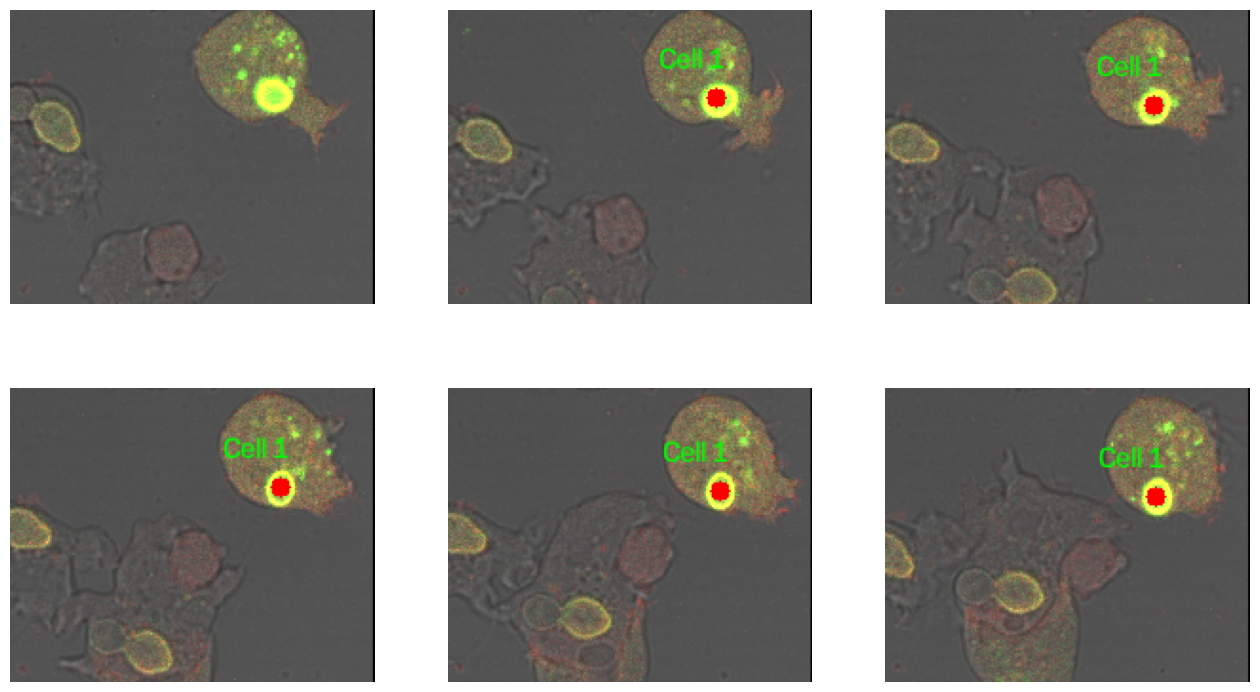

In [45]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 9)
)

for ax, frame_result in zip(
    axes.flat,
    frames_to_show
):
    
    ax.imshow(
        cv2.cvtColor(
            frame_result,
            cv2.COLOR_BGR2RGB
        )
    )
    
    ax.axis("off")

plt.show()

In [46]:
def track_video(
    video_path,
    output_path,
    green_min=175,
    erosion_radius=4,
    min_area=50,
    max_area=400,
    max_distance=200
):
    
    cap = cv2.VideoCapture(
        str(video_path)
    )
    
    if not cap.isOpened():
        raise RuntimeError(
            f"Could not open: {video_path}"
        )
    
    fps = cap.get(
        cv2.CAP_PROP_FPS
    )
    
    width = int(
        cap.get(
            cv2.CAP_PROP_FRAME_WIDTH
        )
    )
    
    height = int(
        cap.get(
            cv2.CAP_PROP_FRAME_HEIGHT
        )
    )
    
    total_frames = int(
        cap.get(
            cv2.CAP_PROP_FRAME_COUNT
        )
    )
    
    fourcc = cv2.VideoWriter_fourcc(
        *"mp4v"
    )
    
    writer = cv2.VideoWriter(
        str(output_path),
        fourcc,
        fps,
        (width, height)
    )
    
    tracker = CellTracker(
        max_distance=max_distance
    )
    
    history = defaultdict(list)
    
    frame_number = 0
    
    while True:
        
        ret, frame = cap.read()
        
        if not ret:
            break
        
        # Detection
        detections, _ = detect_cells(
            frame,
            green_min=green_min,
            erosion_radius=erosion_radius,
            min_area=min_area,
            max_area=max_area
        )
        
        # Tracking
        tracks = tracker.update(
            detections,
            frame_number
        )
        
        # Save history
        for track in tracks:
            
            if track.confirmed:
                
                x, y = track.tracked_position
                
                history[
                    track.track_id
                ].append(
                    (frame_number, x, y)
                )
        
        # Visualization
        result = draw_tracks(
            frame,
            tracks
        )
        
        writer.write(result)
        
        frame_number += 1
        
        if frame_number % 50 == 0:
            
            print(
                f"Processed "
                f"{frame_number}/{total_frames}"
            )
    
    cap.release()
    writer.release()
    
    return history

In [47]:
TRACKING_OUTPUT = (
    OUTPUT_DIR / "cell_tracking.mp4"
)

history = track_video(
    VIDEO_PATH,
    TRACKING_OUTPUT
)

print(
    "Tracking video saved to:",
    TRACKING_OUTPUT
)

Processed 50/300
Processed 100/300
Processed 150/300
Processed 200/300
Processed 250/300
Processed 300/300
Tracking video saved to: c:\Users\Sanjarbek\maab\cv\computer-vision-roadmap\content\object-tracking\output\cell_tracking.mp4


In [48]:
confirmed_tracks = []

for track_id, positions in history.items():
    
    if len(positions) > 0:
        
        first_frame = positions[0][0]
        
        confirmed_tracks.append({
            "track_id": track_id,
            "confirmed_frame": first_frame,
            "number_of_frames": len(positions)
        })

confirmed_tracks

[{'track_id': 1, 'confirmed_frame': 3, 'number_of_frames': 133},
 {'track_id': 3, 'confirmed_frame': 105, 'number_of_frames': 195}]

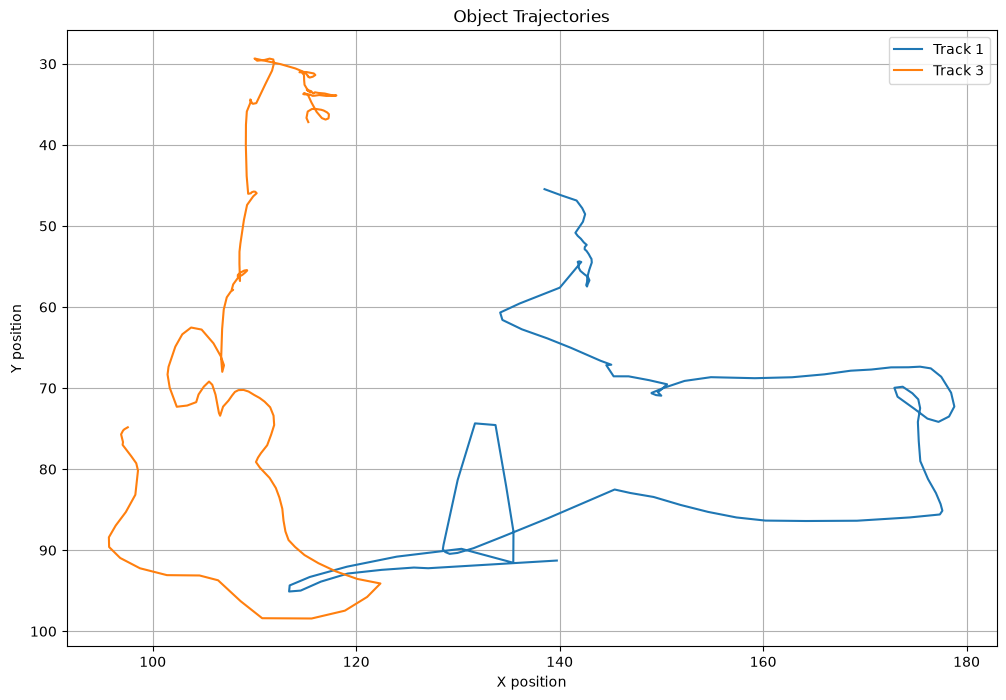

In [49]:
plt.figure(figsize=(12, 8))

for track_id, positions in history.items():
    
    if len(positions) < 5:
        continue
    
    xs = [
        p[1]
        for p in positions
    ]
    
    ys = [
        p[2]
        for p in positions
    ]
    
    plt.plot(
        xs,
        ys,
        label=f"Track {track_id}"
    )

plt.gca().invert_yaxis()

plt.xlabel("X position")
plt.ylabel("Y position")

plt.title(
    "Object Trajectories"
)

plt.legend()

plt.grid(True)

plt.show()

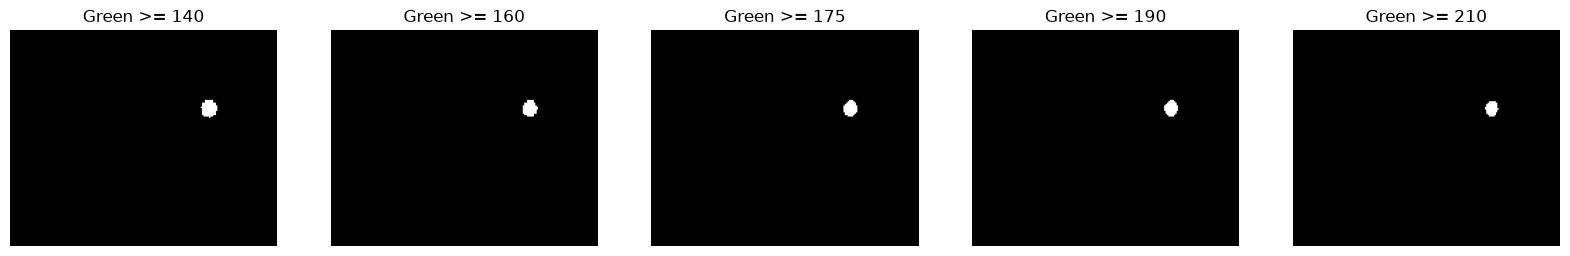

In [50]:
thresholds = [
    140,
    160,
    175,
    190,
    210
]

fig, axes = plt.subplots(
    1,
    len(thresholds),
    figsize=(20, 4)
)

for ax, threshold in zip(
    axes,
    thresholds
):
    
    test_mask = segment_cells(
        frame,
        green_min=threshold
    )
    
    ax.imshow(
        test_mask,
        cmap="gray"
    )
    
    ax.set_title(
        f"Green >= {threshold}"
    )
    
    ax.axis("off")

plt.show()

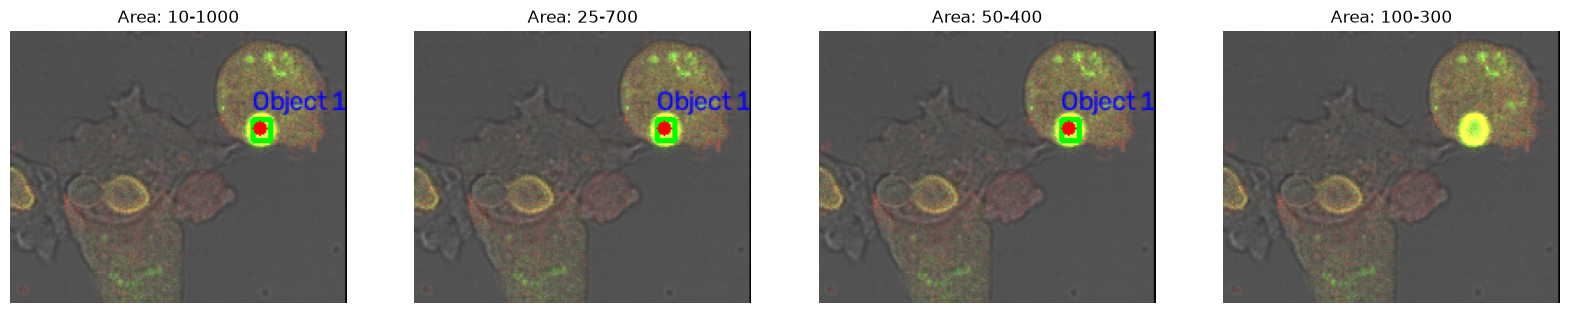

In [51]:
area_ranges = [
    (10, 1000),
    (25, 700),
    (50, 400),
    (100, 300)
]

fig, axes = plt.subplots(
    1,
    4,
    figsize=(20, 5)
)

for ax, (
    min_area,
    max_area
) in zip(
    axes,
    area_ranges
):
    
    detections, _ = detect_cells(
        frame,
        min_area=min_area,
        max_area=max_area
    )
    
    result = draw_detections(
        frame,
        detections
    )
    
    ax.imshow(
        cv2.cvtColor(
            result,
            cv2.COLOR_BGR2RGB
        )
    )
    
    ax.set_title(
        f"Area: {min_area}-{max_area}"
    )
    
    ax.axis("off")

plt.show()

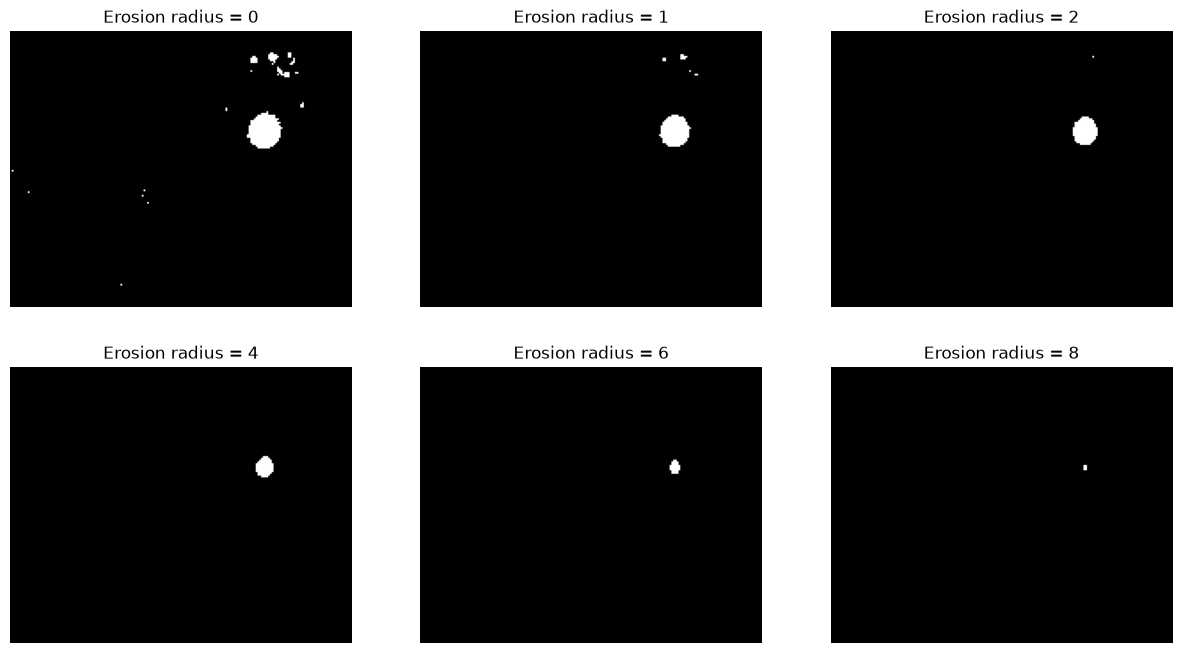

In [52]:
radii = [0, 1, 2, 4, 6, 8]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 8)
)

for ax, radius in zip(
    axes.flat,
    radii
):
    
    mask_test = segment_cells(
        frame,
        erosion_radius=radius
    )
    
    ax.imshow(
        mask_test,
        cmap="gray"
    )
    
    ax.set_title(
        f"Erosion radius = {radius}"
    )
    
    ax.axis("off")

plt.show()

# Object Detection Cheat Sheet

## Segmentation

Converts an image into:

foreground vs background

---

## Binary Mask

0   → background
255 → foreground

---

## Morphology

Erosion:
shrinks foreground regions.

Dilation:
expands foreground regions.

Opening:
erosion → dilation

Closing:
dilation → erosion

Hole filling:
fills internal holes.

---

## Connected Components

Find separate objects inside a binary mask.

---

## Area Filtering

Remove objects that are:

too small
or
too large

---

## Centroid

Represents the center position of an object.

(x, y)

---

## Bounding Box

(x, y, width, height)

---

## Detection

Find objects independently in each frame.

---

## Tracking

Maintain object identity across frames.

---

## Kalman Filter

Predicts where an object should be.

State:

x
y
vx
vy

---

## Assignment

Match detections to existing tracks.

Example:

Track 1 → Detection 3
Track 2 → Detection 1
Track 3 → Detection 2

---

## Track Confirmation

Don't trust a new track immediately.

Require several successful observations.

---

## Lost Track

Delete tracks that haven't been observed
for too many frames.

# Complete Mental Model

                 VIDEO
                   │
                   ▼
              Read Frame
                   │
                   ▼
           Color Segmentation
                   │
                   ▼
             Binary Mask
                   │
                   ▼
            Fill Holes
                   │
                   ▼
              Erosion
                   │
                   ▼
        Connected Components
                   │
                   ▼
            Area Filtering
                   │
                   ▼
       ┌─────────────────────┐
       │     DETECTIONS      │
       │                     │
       │ centroid            │
       │ bounding box        │
       │ area                │
       └─────────────────────┘
                   │
                   ▼
             PREDICTION
                   │
                   ▼
              ASSIGNMENT
                   │
                   ▼
                UPDATE
                   │
                   ▼
           TRACK MANAGEMENT
           /       |       \
          /        |        \
    Confirm     Continue    Delete
      track       track      track
          \        |        /
           \       |       /
              TRACK IDs
                   │
                   ▼
             Visualization
                   │
                   ▼
              Output Video